# FraudGuard — 02: Veri Ön İşleme

**Kural:** StandardScaler yalnızca `X_train` üzerinde fit edilir; `X_test`'e sadece `transform` uygulanır.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
METRICS_DIR   = Path('../results/metrics')
FIGURES_DIR   = Path('../results/figures')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
with open('../config/model_params.yaml', 'r') as f:
    cfg = yaml.safe_load(f)
print('Config loaded.')

Config loaded.


## 1. Split'leri Yükle (Step 02'den)

In [3]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train fraud rate: {y_train.mean():.4%}')
print(f'y_test  fraud rate: {y_test.mean():.4%}')

X_train: (227845, 30)  |  X_test: (56962, 30)
y_train fraud rate: 0.1729%
y_test  fraud rate: 0.1720%


## 2. Scaling Öncesi İstatistikler

In [4]:
before_stats = X_train[['Amount', 'Time']].describe().round(4)
print('Scaling öncesi — Amount ve Time (train):')
print(before_stats)

Scaling öncesi — Amount ve Time (train):
            Amount         Time
count  227845.0000  227845.0000
mean       88.1763   94885.0937
std       250.7226   47488.4150
min         0.0000       0.0000
25%         5.6400   54228.0000
50%        22.0000   84805.0000
75%        77.4900  139364.0000
max     25691.1600  172792.0000


## 3. StandardScaler — Yalnızca Train'e Fit

In [5]:
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = X_train.copy()
X_train_scaled[X_train.columns] = scaler.fit_transform(X_train)

# Transform test data using train statistics — no fitting on test
X_test_scaled = X_test.copy()
X_test_scaled[X_test.columns] = scaler.transform(X_test)

print('Scaler fit edildi (train) ve transform uygulandı (train + test).')
print(f'Scaler mean_[:3]: {scaler.mean_[:3].round(4)}')
print(f'Scaler scale_[:3]: {scaler.scale_[:3].round(4)}')

Scaler fit edildi (train) ve transform uygulandı (train + test).
Scaler mean_[:3]: [ 9.48850937e+04  8.00000000e-04 -5.00000000e-04]
Scaler scale_[:3]: [4.74883108e+04 1.95890000e+00 1.64910000e+00]


## 4. Scaling Sonrası Doğrulama

In [6]:
after_stats = X_train_scaled[['Amount', 'Time']].describe().round(4)
print('Scaling sonrası — Amount ve Time (train):')
print(after_stats)

# Verify: train mean ~0, std ~1
assert abs(X_train_scaled.mean().mean()) < 0.01, 'HATA: train mean sıfırdan uzak!'
assert abs(X_train_scaled.std().mean() - 1.0) < 0.05, 'HATA: train std 1.0 değil!'
print('\nDoğrulama geçti: train mean ≈ 0, train std ≈ 1')

Scaling sonrası — Amount ve Time (train):
            Amount         Time
count  227845.0000  227845.0000
mean        0.0000      -0.0000
std         1.0000       1.0000
min        -0.3517      -1.9981
25%        -0.3292      -0.8561
50%        -0.2639      -0.2123
75%        -0.0426       0.9366
max       102.1170       1.6405

Doğrulama geçti: train mean ≈ 0, train std ≈ 1


## 5. Görsel: Amount Dağılımı — Scaling Öncesi / Sonrası

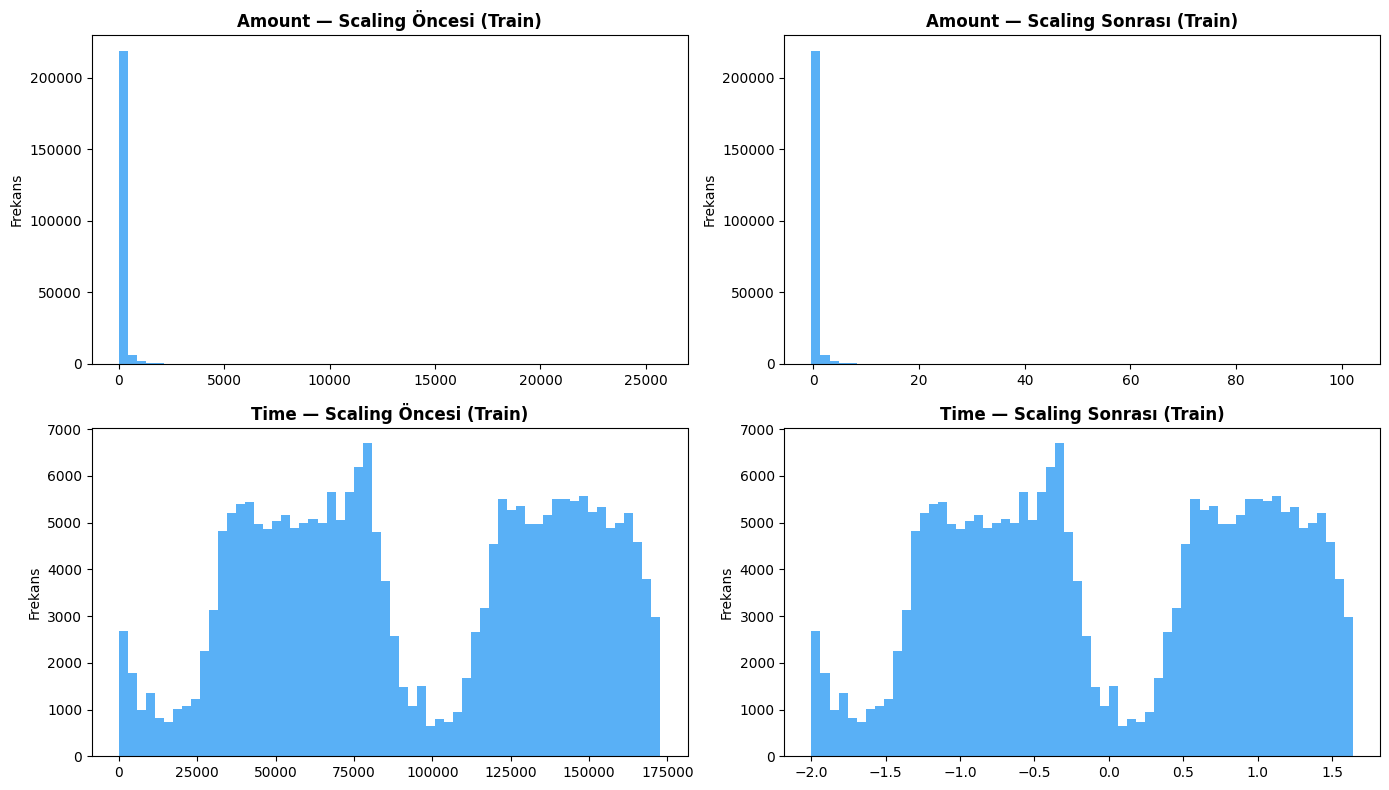

Saved: 06_scaling_comparison.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, data, title in zip(
    axes.flatten(),
    [X_train['Amount'], X_train_scaled['Amount'],
     X_train['Time'],   X_train_scaled['Time']],
    ['Amount — Scaling Öncesi (Train)', 'Amount — Scaling Sonrası (Train)',
     'Time — Scaling Öncesi (Train)',   'Time — Scaling Sonrası (Train)']
):
    ax.hist(data, bins=60, color='#2196F3', alpha=0.75, edgecolor='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frekans')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_scaling_comparison.png')

## 6. Kaydet

In [8]:
# Save scaled splits
X_train_scaled.to_csv(PROCESSED_DIR / 'X_train_scaled.csv', index=False)
X_test_scaled.to_csv(PROCESSED_DIR  / 'X_test_scaled.csv',  index=False)

# Save scaler
joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')

print('X_train_scaled.csv kaydedildi.')
print('X_test_scaled.csv  kaydedildi.')
print('scaler.pkl         kaydedildi.')

X_train_scaled.csv kaydedildi.
X_test_scaled.csv  kaydedildi.
scaler.pkl         kaydedildi.


## 7. Ön İşleme Raporu — JSON

In [9]:
report = {
    'scaler': 'StandardScaler',
    'fit_on': 'X_train only',
    'n_features': int(X_train.shape[1]),
    'amount_before': {
        'mean': round(float(X_train['Amount'].mean()), 4),
        'std':  round(float(X_train['Amount'].std()),  4),
        'min':  round(float(X_train['Amount'].min()),  4),
        'max':  round(float(X_train['Amount'].max()),  4)
    },
    'amount_after': {
        'mean': round(float(X_train_scaled['Amount'].mean()), 6),
        'std':  round(float(X_train_scaled['Amount'].std()),  6)
    },
    'leakage_check': {
        'scaler_fitted_on_test': False,
        'train_mean_near_zero': bool(abs(X_train_scaled.mean().mean()) < 0.01),
        'train_std_near_one':   bool(abs(X_train_scaled.std().mean() - 1.0) < 0.05)
    }
}

with open(METRICS_DIR / '03_preprocessing_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print(json.dumps(report, indent=2))
print('\nSaved: 03_preprocessing_report.json')

{
  "scaler": "StandardScaler",
  "fit_on": "X_train only",
  "n_features": 30,
  "amount_before": {
    "mean": 88.1763,
    "std": 250.7226,
    "min": 0.0,
    "max": 25691.16
  },
  "amount_after": {
    "mean": 0.0,
    "std": 1.000002
  },
  "leakage_check": {
    "scaler_fitted_on_test": false,
    "train_mean_near_zero": true,
    "train_std_near_one": true
  }
}

Saved: 03_preprocessing_report.json
